In [6]:
import pandas as pd
import matplotlib.pyplot as plt

def read_and_clean(path, skiprows=33):
    # Spaltennamen (index, datum, Intervall, CH1..CH11, Alarm-Felder)
    names = ['index', 'datetime', 'interval'] + [f'CH{i}' for i in range(1, 12)] + ['Alarm1_10', 'Alarm11_20', 'AlarmOut']
    df = pd.read_csv(path, skiprows=skiprows, header=None, names=names,
                     sep=',', engine='python', skipinitialspace=True, dtype=str)

    # Entferne komplett leere Spalten (z.B. führende Tabs)
    if df.shape[1] > len(names):
        df = df.loc[:, ~df.apply(lambda col: col.astype(str).str.strip().replace('', pd.NA).isna().all())]

    # Datum parsen
    df['datetime'] = pd.to_datetime(df['datetime'].astype(str).str.strip(), format='%Y/%m/%d %H:%M:%S', errors='coerce')

    # CH-Spalten aufräumen und in floats konvertieren
    ch_cols = [f'CH{i}' for i in range(1, 12)]
    for c in ch_cols:
        if c in df.columns:
            df[c] = df[c].astype(str).str.replace(r'[+\s]', '', regex=True).str.replace(',', '.', regex=False)
            df[c] = pd.to_numeric(df[c], errors='coerce')

    return df, ch_cols

def plot_channels(df, ch_cols, out_file=None):
    plt.figure(figsize=(12, 6))
    for ch in ch_cols:
        if ch in df.columns:
            plt.plot(df['datetime'], df[ch], marker='', label=ch)
    plt.xlabel('Zeit')
    plt.ylabel('Wert')
    plt.title('CH1 .. CH11')
    plt.legend(ncol=2)
    plt.tight_layout()
    if out_file:
        plt.savefig(out_file, dpi=200)
        print(f'Plot gespeichert: {out_file}')
    else:
        plt.show()

# Use the notebook cells below to load and plot a CSV (no argparse / CLI in the notebook)


# Anleitung — CSV plotten (CH1..CH11) 

- Header: bis Zeile 33 (Standard: `skiprows=33`)
- Dateiformat: `YYYY/MM/DD HH:MM:SS` (bei Abweichung anpassen)
- Standard-Dateipfad: `data/260203-084845.CSV`

Führe die nächste Code-Zelle aus, um die Datei zu laden, zu prüfen und den Plot inline anzuzeigen.

Zeilen gelesen: 204 — Zeitspalten mit NaN: 0


,index,datetime,interval,CH1,CH2,CH3,CH4,CH5,CH6,CH7,CH8,CH9,CH10,CH11,Alarm1_10,Alarm11_20,AlarmOut
0,1,2026-02-03 08:48:45,0,22.50,22.75,22.75,22.80,22.70,22.50,22.60,22.35,22.70,0.033,0.182,LLLLLLLLLL,LLLLLLLLLL,LLLL
1,2,2026-02-03 08:48:45,250,22.50,22.60,22.90,22.70,22.70,22.50,22.45,22.60,22.70,0.029,-0.029,LLLLLLLLLL,LLLLLLLLLL,LLLL
2,3,2026-02-03 08:48:45,500,22.45,22.65,22.65,22.70,22.65,22.45,22.55,22.30,22.65,0.033,0.177,LLLLLLLLLL,LLLLLLLLLL,LLLL
3,4,2026-02-03 08:48:45,750,22.45,22.50,22.80,22.65,22.65,22.50,22.35,22.55,22.60,0.029,-0.028,LLLLLLLLLL,LLLLLLLLLL,LLLL
4,5,2026-02-03 08:48:46,0,22.45,22.65,22.60,22.70,22.65,22.45,22.55,22.35,22.70,0.033,0.172,LLLLLLLLLL,LLLLLLLLLL,LLLL


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   index       204 non-null    object        
 1   datetime    204 non-null    datetime64[ns]
 2   interval    204 non-null    object        
 3   CH1         204 non-null    float64       
 4   CH2         204 non-null    float64       
 5   CH3         204 non-null    float64       
 6   CH4         204 non-null    float64       
 7   CH5         204 non-null    float64       
 8   CH6         204 non-null    float64       
 9   CH7         204 non-null    float64       
 10  CH8         204 non-null    float64       
 11  CH9         204 non-null    float64       
 12  CH10        204 non-null    float64       
 13  CH11        204 non-null    float64       
 14  Alarm1_10   204 non-null    object        
 15  Alarm11_20  204 non-null    object        
 16  AlarmOut    204 non-null  

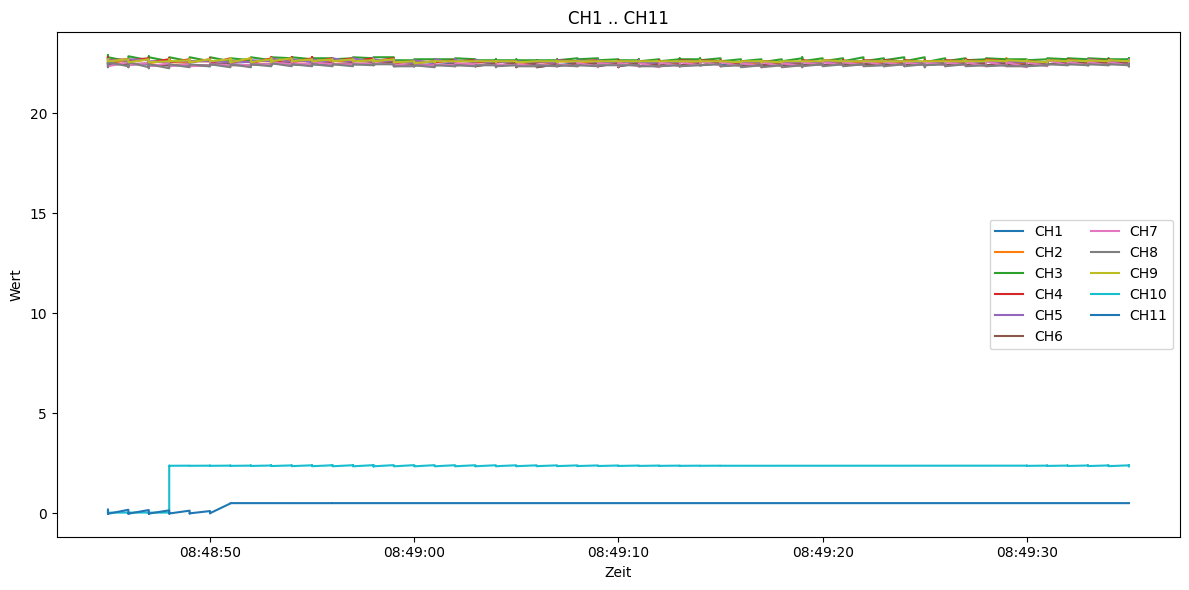

In [8]:
# Notebook: CSV laden und plotten
%matplotlib inline

CSV_PATH = 'data/260203-084845.CSV'  # Passe bei Bedarf an

df, ch_cols = read_and_clean(CSV_PATH, skiprows=33)
print(f'Zeilen gelesen: {len(df)} — Zeitspalten mit NaN: {df["datetime"].isna().sum()}')

display(df.head())
df.info()

# Plot inline
plot_channels(df, ch_cols)

# Optional: plot speichern
# plot_channels(df, ch_cols, out_file='plot.png')